# 1. Load the Packages

In [10]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from datetime import datetime, date, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

# 2. Load the dataset (set the directory)

In [11]:
# Set the working directory to the location of the data file
import os 
os.chdir('/Users/surajgurung/Library/CloudStorage/OneDrive-UniversityofFlorida/AI&FINtech/JPMorgan_Simulation')


# Load the data set
df = pd.read_csv('Nat_Gas.csv')
# Ensure dates are parsed as datetime for plotting/regression
df['Dates'] = pd.to_datetime(df['Dates'])
prices = df['Prices'].values  # y
dates = df['Dates'].values  # x

/var/folders/71/dvyytfpj799079751h_7f5tm0000gn/T/ipykernel_14832/1578105638.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


# 3. Plot the price against dates

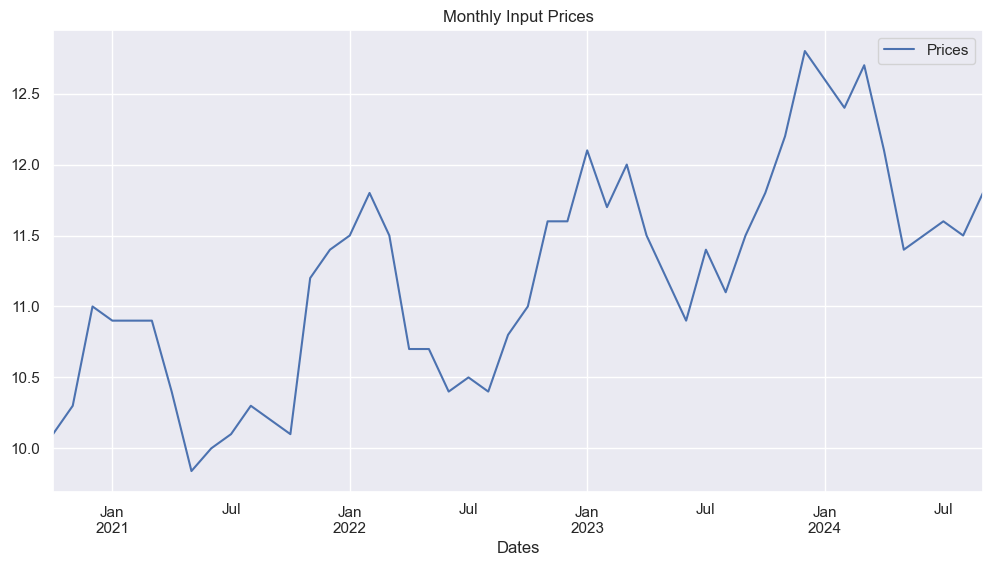

In [12]:
# Plot the price against (Simplest way using pandas)
df.plot(x='Dates', y='Prices', title='Monthly Input Prices', figsize=(12, 6))
plt.show()  

From the plot we see that the price of natural gas has been increasing over time, with some fluctuations. The price seems to have a general upward trend, especially in the later years. There are also some noticeable spikes in the price, which could be due to various factors such as supply and demand, geopolitical events, or changes in production levels. Overall, the plot indicates that natural gas prices have been rising over the period covered by the data.

# 4. Run a simple linear regression 
- To get the trends and then fit a sin function to the variation in each year

In [13]:
# This is
#  start_date = date(2020,10,31)

# end_date = date(2024,9,30)
# months = []
# year = start_date.year
# month = start_date.month + 1
# while True:
#     current = date(year, month, 1) + timedelta(days=-1)
#     months.append(current)
#     if current.month == end_date.month and current.year == end_date.year:
#         break
#     else:
#         month = ((month + 1) % 12) or 12
#         if month == 1:
#             year += 1
        
# days_from_start = [(day - start_date ).days for day in months]

# # Simple regression for the trend will fit to a model y = Ax + B. The estimator for the slope is given by \hat{A} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, 
# # and that for the intercept by \hat{B} = \bar{y} - hat{A} * \xbar
# def simple_regression(x, y):
#     xbar = np.mean(x)
#     ybar = np.mean(y)
#     slope = np.sum((x - xbar) * (y - ybar))/ np.sum((x - xbar)**2)
#     intercept = ybar - slope*xbar
#     return slope, intercept

# time = np.array(days_from_start)
# slope, intercept = simple_regression(time, prices)


The slope = 0.0012 and Intercept = 10.29

In [14]:
from scipy.stats import linregress

# Convert dates to numeric (days from start)
start_date = date(2020, 10, 31)
end_date = date(2024, 9, 30)

dates_converted = pd.to_datetime(dates)
x = np.array([(d - pd.Timestamp(start_date)).days for d in dates_converted])
y = prices

# Now do the regression
result = linregress(x, y)
slope = result.slope
intercept = result.intercept
print(f"Slope: {slope}, Intercept: {intercept}")



Slope: 0.001282373598760221, Intercept: 10.29104112595228


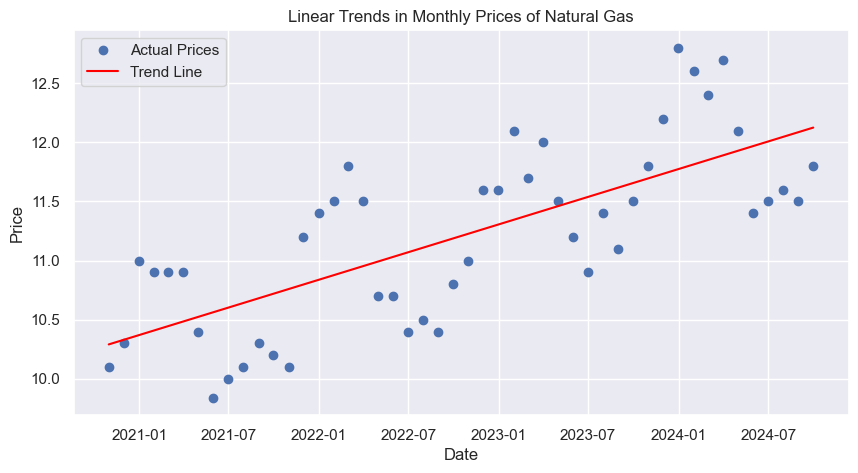

In [15]:
# Plot the data and the trend line
trend_line = slope * x + intercept

plt.figure(figsize=(10, 5))
plt.plot(dates_converted, y, 'o', label='Actual Prices')
plt.plot(dates_converted, trend_line, '-', color='red', label='Trend Line')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Linear Trends in Monthly Prices of Natural Gas')
plt.legend()
plt.grid(True)
plt.show()



From this plot we see the linear trend has been captured. Now to fit the intra-year variation. 
Given that natural gas is used more in winter, and less in summer, we can guess the frequency of the price movements to be about a year, or 12 months.
Therefore we have a model y = Asin( kt + z ) with a known frequency.
Rewriting y = Acos(z)sin(kt) + Asin(z)cos(kt), 
we can use bilinear regression, with no intercept, to solve for u = Acos(z), w = Asin(z)

In [16]:
sin_prices = prices - (x * slope + intercept)
sin_time = np.sin(x * 2 * np.pi / 365)
cos_time = np.cos(x * 2 * np.pi / 365)

X = np.column_stack([sin_time, cos_time])

u, w = np.linalg.lstsq(X, sin_prices, rcond=None)[0]

print("u =", u)
print("w =", w)

A = np.sqrt(u**2 + w**2)
z = np.arctan2(w, u)

print("Amplitude =", A)
print("Phase =", z)

seasonal_fit = u * sin_time + w * cos_time
full_fit = x * slope + intercept + seasonal_fit

u = 0.6643397800788301
w = -0.03858317455872708
Amplitude = 0.6654592434959616
Phase = -0.058012304909436985


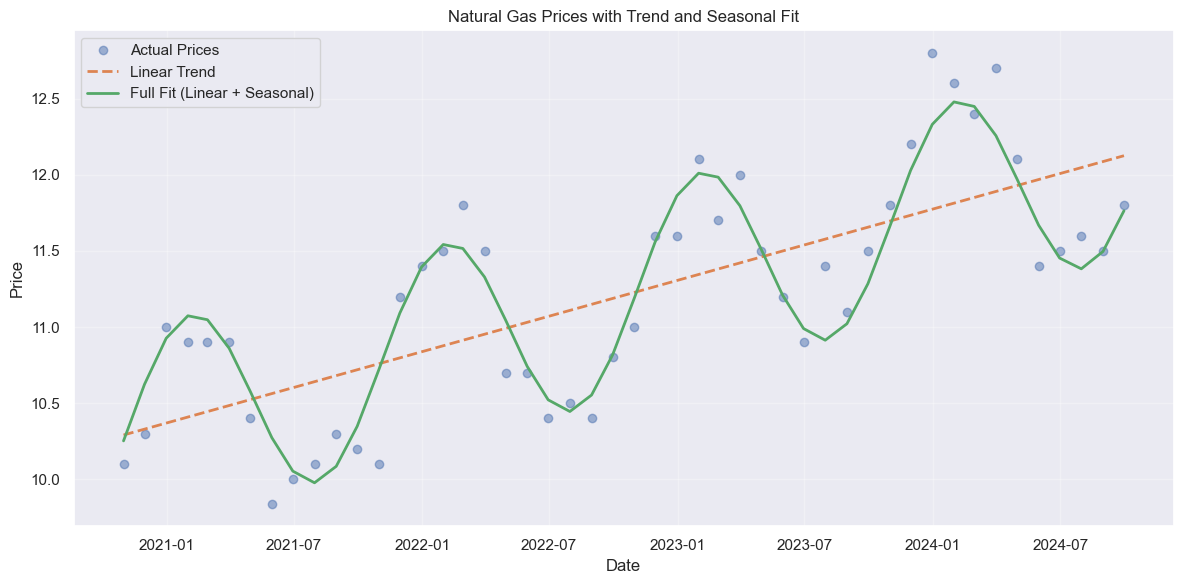

In [17]:
trend_fit = x * slope + intercept

plt.figure(figsize=(12, 6))
plt.plot(dates_converted, y, 'o', alpha=0.5, label='Actual Prices')
plt.plot(dates_converted, trend_fit, '--', linewidth=2, label='Linear Trend')
plt.plot(dates_converted, full_fit, '-', linewidth=2, label='Full Fit (Linear + Seasonal)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices with Trend and Seasonal Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 5. Prediction Part

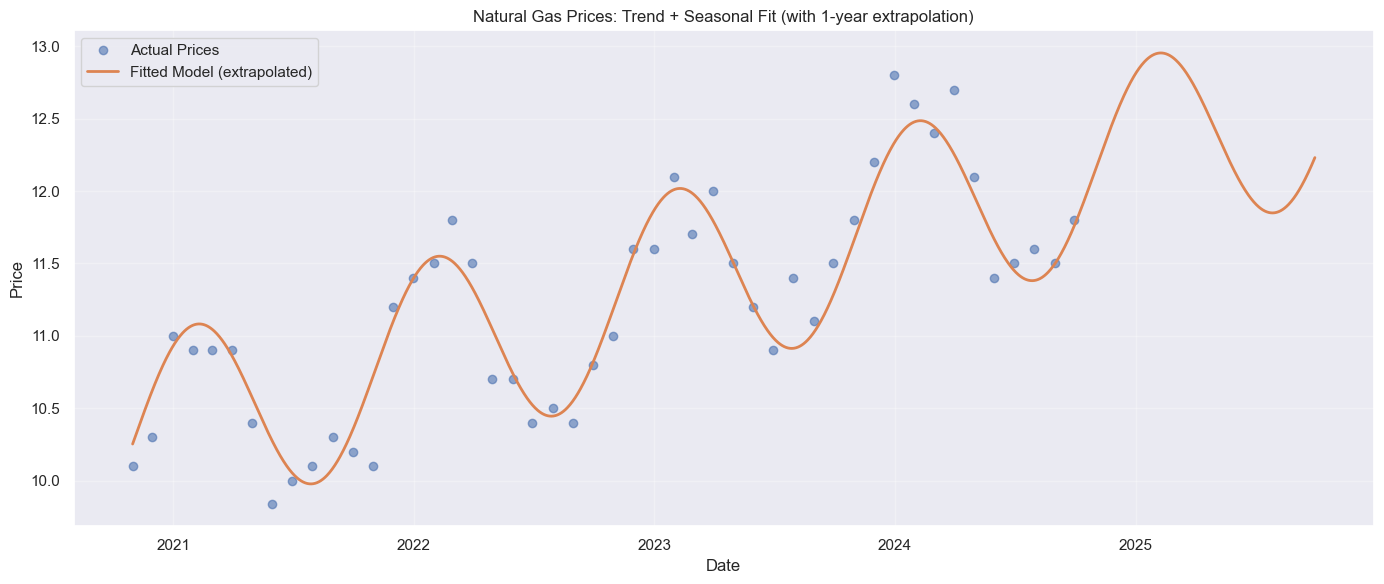

Extrapolation range: 2020-10-31 to 2025-09-30


In [18]:
k = 2 * np.pi / 365

def predict_price(days):
    return slope * days + intercept + A * np.sin(k * days + z)

# Extrapolate for 1 year beyond the last observed date
last_date = dates_converted.max()
end_date = last_date + pd.DateOffset(years=1)

# Daily dates for a smooth curve
continuous_dates = pd.date_range(start=dates_converted.min(),
                                 end=end_date,
                                 freq='D')

continuous_days = (continuous_dates - pd.Timestamp(start_date)).days.to_numpy()

fitted_prices = predict_price(continuous_days)

plt.figure(figsize=(14, 6))
plt.plot(dates_converted, prices, 'o', alpha=0.6, label='Actual Prices')
plt.plot(continuous_dates, fitted_prices, '-', linewidth=2, label='Fitted Model (extrapolated)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices: Trend + Seasonal Fit (with 1-year extrapolation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Extrapolation range: {dates_converted.min().date()} to {end_date.date()}")